In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc

In [28]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist


def calculate_centroid_accuracies(agg_post_pred_df, post_gt_all_df):
    """
    Calculates the centroid accuracies for all given perturbations and methods

    Arguments:
        agg_post_pred_df: pandas df with the inferred post-perturbation profiles of each method. Columns correspond to genes. Each row corresponds to the predictions of a method for a given test perturbation. Expects a DataFrame with a _MultiIndex_, where the first index is the condition (test perturbation) and the second is the method. For example:

        post_gt_all_df:  Pd df with the gt post-pert profiles. rows: perturbations, columns: genes.

    Returns 
        a Pandas df with the centroid accuracies of each method for each test perturbation.
    """
    distances = cdist(agg_post_pred_df, post_gt_all_df, metric='euclidean')
    dist_df = pd.DataFrame(distances, index=agg_post_pred_df.index, columns=post_gt_all_df.index)
    
    # Self distances
    index = [g for g in dist_df.index.get_level_values(0) if g in dist_df.columns]
    multiindex = [(g, m) for g, m in dist_df.index if g in dist_df.columns]
    col_idxs = [np.argwhere(dist_df.columns == g)[0][0] for g in index]
    self_distances = np.diag(dist_df.iloc[np.arange(len(dist_df)), col_idxs])
    self_distances_df = pd.DataFrame(self_distances, index=pd.MultiIndex.from_tuples(multiindex))
    assert np.all(dist_df.index == self_distances_df.index)

    scores = {}
    methods = agg_post_pred_df.index.get_level_values(1).unique()
    for method in methods:
        x_df = dist_df.xs(method, level=1).sort_index()
        y_df = self_distances_df.xs(method, level=1).sort_index()
        assert np.all(x_df.index == y_df.index)
        scores[method] = ((x_df > y_df.values).sum(axis=1)) / (x_df.shape[-1] - 1)
    scores_df = pd.DataFrame(scores)
    return scores_df

In [2]:
def get_implemented_CA(agg_post_pred_df, post_gt_all_df):

    n_perts = len(post_gt_all_df)
    results = {}
    for method in methods:
        results[method] = {}
        for cond in tqdm(conds):
            euclideans = []
            query_idx = post_gt_all_df.index.tolist().index(cond)
            for n_index in range(len(post_gt_all_df)):
                _pred = agg_post_pred_df.loc[(cond, method)].values
                _gt = post_gt_all_df.iloc[n_index].values
                _dist = ((_pred - _gt) ** 2).sum()
                euclideans.append(_dist)

            _indices = np.argsort(np.argsort(euclideans))
            rank = _indices[query_idx]
            score = 1 - (rank / (n_perts-1))
            results[method][cond] = score
    
    return results

In [3]:
preds_path = f'{os.environ["SCDIS_ROOT"]}/Benchmarks/'


methods = ['CPA', 'GEARS', 'SCDISENTANGLE']

In [4]:
adata_org = sc.read(
    f'{os.environ["SCDIS_ROOT"]}/Datasets/preprocessed_datasets/norman.h5ad'
)

median = adata_org.uns['single_perts_median']

sc.pp.normalize_total(adata_org, target_sum=median)
sc.pp.log1p(adata_org)

In [5]:
conds = adata_org.obs['cond_harm'].unique().tolist()
conds = [x for x in conds if '+' in x]

In [7]:
# make multi_index
pred_centroids = {}
for cond in conds:
    pred_centroids[cond] = {}
    for method in methods:
        if method == 'GEARS':
            cond_name = cond.replace('+', '_')
        else:
            cond_name = cond
            
        _adata_all = sc.read(f'{preds_path}{method}/Norman/predictions/combinatorially_seen/{cond_name}.h5ad')
        _adata = _adata_all[_adata_all.obs['cond_harm_pred'] == cond].copy()

        if method in ['CPA', 'SCDISENTANGLE']:
            print('normalizing', method)
            sc.pp.normalize_total(_adata, target_sum=median)
            sc.pp.log1p(_adata)
            
        _predicted_centroid = _adata.X.mean(axis=0)

        if method == 'SCDISENTANGLE':
            print(method, 'Calibrating..')
            pert1 = adata_org[adata_org.obs['cond_harm'] == cond.split('+')[0]].X.mean(axis=0)
            pert2 = adata_org[adata_org.obs['cond_harm'] == cond.split('+')[1]].X.mean(axis=0)

            sc.pp.normalize_total(_adata_all, target_sum=median)
            sc.pp.log1p(_adata_all)

            pred_pert1 = _adata_all[_adata_all.obs['cond_harm_pred'] == cond.split('+')[0]].X.mean(axis=0)
            pred_pert2 = _adata_all[_adata_all.obs['cond_harm_pred'] == cond.split('+')[1]].X.mean(axis=0)
            error = ((pert1 - pred_pert1) + (pert2 - pred_pert2)) / 2

            _predicted_centroid = _predicted_centroid + error
            
        pred_centroids[cond][method] = _predicted_centroid

        del _adata, _adata_all, _predicted_centroid
        gc.collect()

/home/SE/miniconda3/envs/cpa/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing CPA


/home/SE/miniconda3/envs/cpa/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing SCDISENTANGLE
SCDISENTANGLE Calibrating..


/home/SE/miniconda3/envs/cpa/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

normalizing SCDISENTANGLE
SCDISENTANGLE Calibrating..


/home/SE/miniconda3/envs/cpa/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing CPA


/home/SE/miniconda3/envs/cpa/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing SCDISENTANGLE
SCDISENTANGLE Calibrating..


In [8]:
rows = {(cond, method): np.asarray(values).flatten()
        for cond, methods in pred_centroids.items()
        for method, values in methods.items()}

df = pd.DataFrame.from_dict(rows, orient='index')
df.index = pd.MultiIndex.from_tuples(df.index, names=['condition', 'method'])

In [9]:
averaged = sc.get.aggregate(adata_org, by='cond_harm', func='mean')
averaged = averaged[averaged.obs['cond_harm'] != 'ctrl'].copy()

In [10]:
post_gt_all_df = pd.DataFrame(
    averaged.layers['mean'], 
    index = averaged.obs['cond_harm'].tolist(),
    columns=adata_org.var_names.tolist()
)

In [11]:
score_df = get_implemented_CA(
    agg_post_pred_df=df, 
    post_gt_all_df=post_gt_all_df
)

100%|█████████████████████████████████████████| 128/128 [00:02<00:00, 53.03it/s]


In [12]:
score = pd.DataFrame(score_df) * 100

In [13]:
score

,CPA,GEARS,SCDISENTANGLE
SET+KLF1,52.192982,51.315789,100.000000
KLF1+BAK1,60.964912,98.684211,99.561404
FOXA3+FOXL2,21.491228,96.929825,94.298246
IRF1+SET,7.894737,10.526316,100.000000
IGDCC3+MAPK1,70.175439,71.491228,100.000000
...,...,...,...
CEBPB+OSR2,47.368421,97.368421,99.561404
PRDM1+CBFA2T3,11.842105,90.350877,98.684211
FOSB+CEBPB,8.333333,95.175439,95.614035
ZBTB10+DLX2,2.192982,40.350877,87.280702


In [14]:
for method in ['CPA', 'GEARS', 'SCDISENTANGLE']:
    values = []
    for cond in score.index.tolist():
        _csv = pd.read_csv(f'{preds_path}y_pred_results/results/Norman/combinatorially_seen/{method}/{cond}.csv', index_col='Metric')
        _value = _csv.loc['Centroid Accuracy', '20']
        values.append(_value)
    score[f'{method}_org'] = values

In [15]:
score

,CPA,GEARS,SCDISENTANGLE,CPA_org,GEARS_org,SCDISENTANGLE_org
SET+KLF1,52.192982,51.315789,100.000000,52.192982,51.315789,100.000000
KLF1+BAK1,60.964912,98.684211,99.561404,60.964912,98.684211,99.561404
FOXA3+FOXL2,21.491228,96.929825,94.298246,21.491228,96.929825,94.298246
IRF1+SET,7.894737,10.526316,100.000000,7.894737,10.526316,100.000000
IGDCC3+MAPK1,70.175439,71.491228,100.000000,70.175439,71.491228,100.000000
...,...,...,...,...,...,...
CEBPB+OSR2,47.368421,97.368421,99.561404,47.368421,97.368421,99.561404
PRDM1+CBFA2T3,11.842105,90.350877,98.684211,11.842105,90.350877,98.684211
FOSB+CEBPB,8.333333,95.175439,95.614035,8.333333,95.175439,95.614035
ZBTB10+DLX2,2.192982,40.350877,87.280702,2.192982,40.350877,87.280702


In [18]:
np.allclose(score['CPA'].tolist(),score['CPA_org'].tolist())

True

In [19]:
np.allclose(score['GEARS'].tolist(),score['GEARS_org'].tolist())

True

In [20]:
np.allclose(score['SCDISENTANGLE'].tolist(),score['SCDISENTANGLE_org'].tolist())

True

In [25]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

/tmp/ipykernel_2374356/1542409818.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


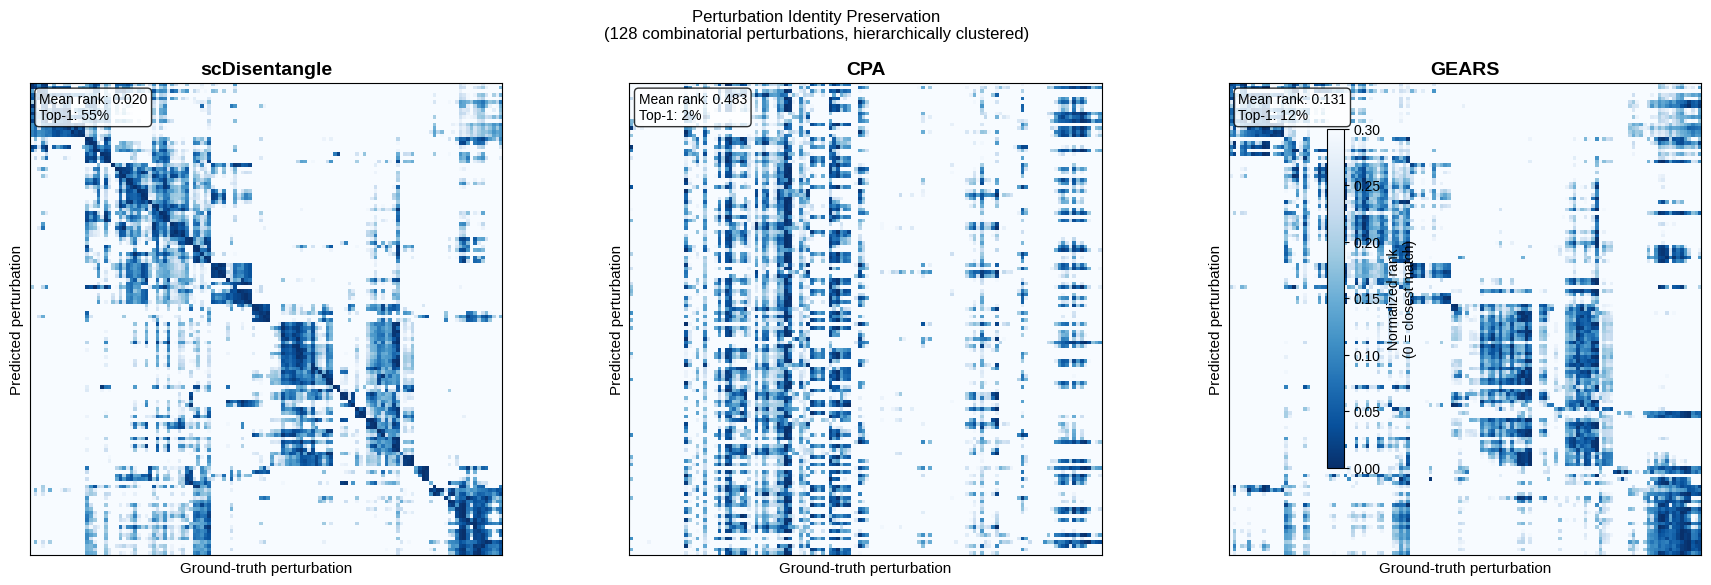


Diagonal rank statistics (lower = better):
  scDisentangle  : mean=0.0205, median=0.0000, top-1=54.7%
  CPA            : mean=0.4829, median=0.4803, top-1=2.3%
  GEARS          : mean=0.1305, median=0.0630, top-1=12.5%


In [26]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


def build_distance_matrix(agg_post_pred_df, post_gt_all_df, method, conds):
    """
    For a given method, compute 128x128 matrix where:
    - Row i = predicted perturbation i
    - Col j = ground-truth perturbation j
    - Value = Euclidean distance between pred_i and gt_j
    """
    post_gt_comb = post_gt_all_df.loc[conds]
    
    n = len(conds)
    dist_mat = np.zeros((n, n))
    
    for i, cond_pred in enumerate(conds):
        pred_vec = agg_post_pred_df.loc[(cond_pred, method)].values
        for j, cond_gt in enumerate(conds):
            gt_vec = post_gt_comb.loc[cond_gt].values
            dist_mat[i, j] = np.sqrt(((pred_vec - gt_vec) ** 2).sum())
    
    return dist_mat

# Build for all three methods
dist_scd = build_distance_matrix(df, post_gt_all_df, 'SCDISENTANGLE', conds)
dist_cpa = build_distance_matrix(df, post_gt_all_df, 'CPA', conds)
dist_gears = build_distance_matrix(df, post_gt_all_df, 'GEARS', conds)

# 2. Convert to rank (more interpretable)

def distance_to_rank(dist_mat):
    n = dist_mat.shape[0]
    rank_mat = np.zeros_like(dist_mat)
    for i in range(n):
        rank_mat[i] = np.argsort(np.argsort(dist_mat[i]))
    return rank_mat / (n - 1)

rank_scd = distance_to_rank(dist_scd)
rank_cpa = distance_to_rank(dist_cpa)
rank_gears = distance_to_rank(dist_gears)

# 3. Reorder by hierarchical clustering (on GT distances)

gt_comb = post_gt_all_df.loc[conds].values
gt_linkage = linkage(gt_comb, method='ward')
order = leaves_list(gt_linkage)

rank_scd_ordered = rank_scd[order][:, order]
rank_cpa_ordered = rank_cpa[order][:, order]
rank_gears_ordered = rank_gears[order][:, order]
conds_ordered = [conds[i] for i in order]

# 4. Plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

cmap = 'Blues_r'
vmin, vmax = 0, 0.3

methods_data = [
    ('scDisentangle', rank_scd_ordered, rank_scd),
    ('CPA', rank_cpa_ordered, rank_cpa),
    ('GEARS', rank_gears_ordered, rank_gears),
]

for ax, (name, rank_ordered, rank_orig) in zip(axes, methods_data):
    im = ax.imshow(rank_ordered, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Ground-truth perturbation', fontsize=11)
    ax.set_ylabel('Predicted perturbation', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    
    diag = np.diag(rank_ordered)
    top1 = (np.diag(rank_orig) == 0).sum() / len(conds) * 100
    ax.text(0.02, 0.98, f'Mean rank: {diag.mean():.3f}\nTop-1: {top1:.0f}%', 
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Normalized rank\n(0 = closest match)', fontsize=10)

plt.suptitle('Perturbation Identity Preservation\n(128 combinatorial perturbations, hierarchically clustered)', 
             fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig('heatmap_perturbation_identity.svg', dpi=600, bbox_inches='tight')
plt.show()

# 5. Summary

print(f"\nDiagonal rank statistics (lower = better):")
for name, rank_mat in [('scDisentangle', rank_scd), ('CPA', rank_cpa), ('GEARS', rank_gears)]:
    diag = np.diag(rank_mat)
    top1 = (diag == 0).sum() / len(conds) * 100
    print(f"  {name:15s}: mean={diag.mean():.4f}, median={np.median(diag):.4f}, top-1={top1:.1f}%")

In [27]:
len(conds)

128

In [29]:
systema_score = calculate_centroid_accuracies(
    agg_post_pred_df=df, 
    post_gt_all_df=post_gt_all_df
) * 100

In [34]:
for method in ['CPA', 'GEARS', 'SCDISENTANGLE']:
    values = []
    for cond in systema_score.index.tolist():
        _csv = pd.read_csv(f'{preds_path}y_pred_results/results/Norman/combinatorially_seen/{method}/{cond}.csv', index_col='Metric')
        _value = _csv.loc['Centroid Accuracy', '20']
        values.append(_value)
    systema_score[f'{method}_org'] = values

In [35]:
systema_score

,CPA,GEARS,SCDISENTANGLE,CPA_org,GEARS_org,SCDISENTANGLE_org
condition,,,,,,
AHR+FEV,36.842105,100.000000,98.684211,36.842105,100.000000,98.684211
AHR+KLF1,100.000000,29.385965,100.000000,100.000000,29.385965,100.000000
BCL2L11+BAK1,33.333333,95.614035,98.245614,33.333333,95.614035,98.245614
BCL2L11+TGFBR2,73.245614,98.684211,99.122807,73.245614,98.684211,99.122807
BPGM+SAMD1,34.649123,97.807018,100.000000,34.649123,97.807018,100.000000
...,...,...,...,...,...,...
ZBTB10+SNAI1,4.385965,85.526316,100.000000,4.385965,85.526316,100.000000
ZC3HAV1+CEBPA,2.631579,98.245614,97.368421,2.631579,98.245614,97.368421
ZC3HAV1+CEBPE,57.017544,97.807018,99.561404,57.017544,97.807018,99.561404


In [36]:
np.allclose(score['CPA'].tolist(),score['CPA_org'].tolist())

True

In [37]:
np.allclose(score['GEARS'].tolist(),score['GEARS_org'].tolist())

True

In [38]:
np.allclose(score['SCDISENTANGLE'].tolist(),score['SCDISENTANGLE_org'].tolist())

True